# Import

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from utils import compute_aligned_loss_energy

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token,
)


# Words

## Tree

[WARN] Record non valutabile (pos 2, line 0): observed_token_not_in_graph (observed_raw='under')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'flu' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'culprit' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'flu' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'blackout' has only 2 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'nonatomic' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'mafia' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token 'blackout' has only 2 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token 'nonatomic' has only 2 occurrences in [0:80] (requested 5)
  [ctx=2000, win_le

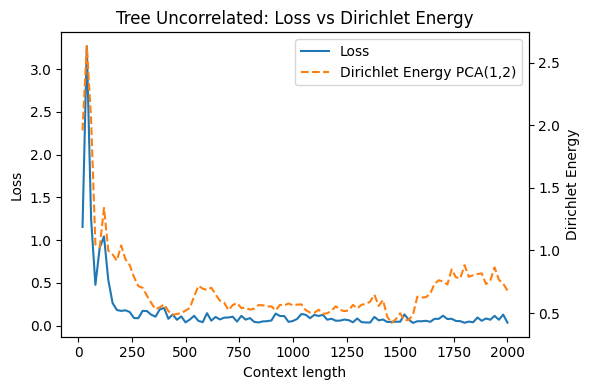

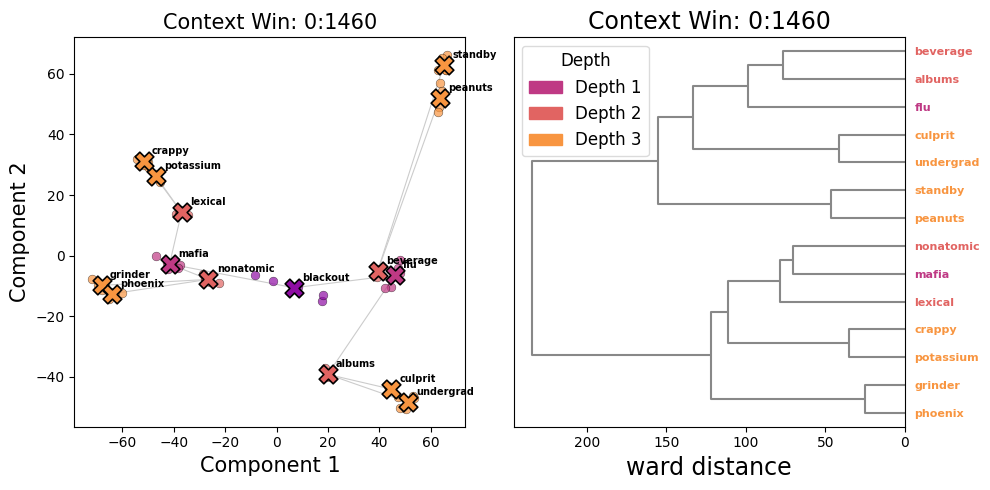

In [2]:
directory = "tree_uncorrelated" 
VOCAB_PATH  = Path("../data/words_dict.txt")
graph_kind = "tree"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

k_last = 5

x_tokens, loss_tree, energy_tree = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_tree, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_tree, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[np.argmin(energy_tree)])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))


embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                    k=k_last, t_start=0, t_end=win_opt)
pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:,0:2]

hp_tree.plot_reduced_emb(axes[0], pca_result, filtered_ids, title=f"Context Win: 0:{win_opt}", only_centroid=False)

# fig.suptitle(directory.replace("_", " ").title(),
#              fontsize=20, y=1.01)


# -------------------------------- DENDROGRAM -------------------------------- #

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 2 # quale livello dell'albero dendrogrammo per i centroidi
layer3 = 1

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2 or depth == layer3]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

mask_layer_l = np.isin(ids_np, ids_layer_l)
emb_dendro = emb_np[mask_layer_l]
ids_dendro = ids_np[mask_layer_l]


centroids_id, centroids_emb = centroids_by_token(ids_dendro, emb_dendro)

hp_tree.plot_dendrogram_on_points(axes[1], centroids_id, centroids_emb, title=f"Context Win: 0:{win_opt}", 
                                  method="ward", max_leaves=50, leaf_font_size=8)

# fig.suptitle(f"Dendrogram Tree Words",
            #  fontsize=15, y=1.01)

fig.tight_layout()
fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

## Grid

[WARN] Record non valutabile (pos 2, line 0): observed_token_not_in_graph (observed_raw='vit')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'peanuts' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'potassium' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'vitae' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'nonatomic' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'standby' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'culprit' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'beverage' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'undergrad' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000,

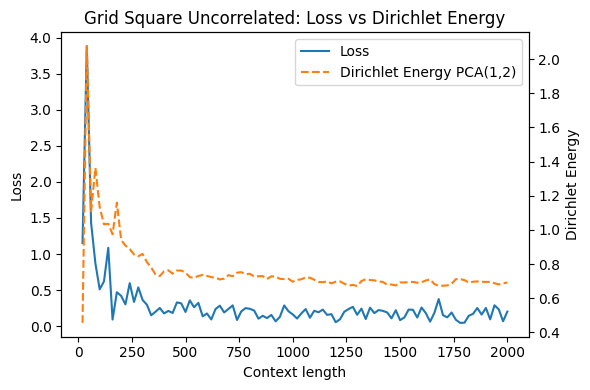

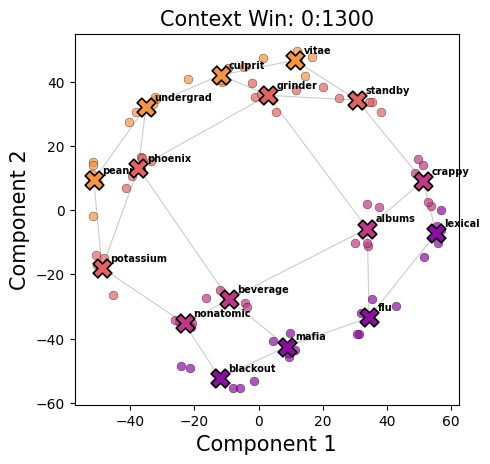

In [3]:
directory = "grid_square_uncorrelated" 
VOCAB_PATH  = Path("../data/words_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)
k_last = 5

x_tokens, loss_grid, energy_grid = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_grid, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_grid, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[2:][np.argmin(energy_grid[2:])])

fig, ax = plt.subplots(figsize=(5, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, :2]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal')
fig.tight_layout()

fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

## Circle

[WARN] Record non valutabile (pos 2, line 0): observed_token_not_in_graph (observed_raw='under')
[WARN] Record non valutabile (pos 12, line 0): None (observed_raw='beverage')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'blackout' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'nonatomic' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'mafia' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'flu' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'culprit' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'beverage' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'blackout' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: t

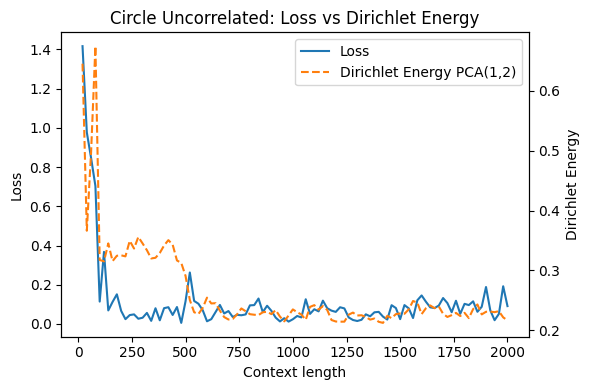

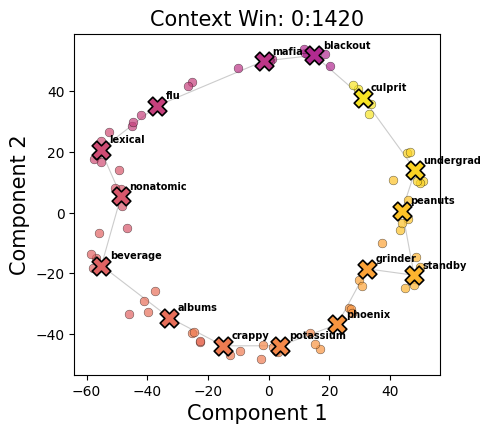

In [4]:
directory = "circle_uncorrelated" 
VOCAB_PATH  = Path("../data/words_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

x_tokens, loss_circle, energy_circle = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_circle, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_circle, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
# fig.savefig(f"../plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[2:][np.argmin(energy_circle[2:])])

fig, ax = plt.subplots(figsize=(5, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, :2]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal')
fig.tight_layout()

fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

## all losses and energies

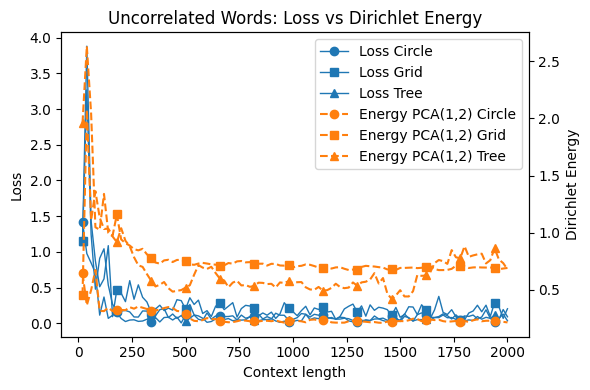

In [5]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

loss_color = "tab:blue"
energy_color = "tab:orange"

# stili per shape
loss_styles = {
    "Circle": dict(linestyle="-",  marker="o", markevery=8),
    "Grid":   dict(linestyle="-",  marker="s", markevery=8),
    "Tree":   dict(linestyle="-",  marker="^", markevery=8),
}

energy_styles = {
    "Circle": dict(linestyle="--", marker="o", markevery=8),              # dashed
    "Grid":   dict(linestyle="--", marker="s", markevery=8),              # dash-dot
    "Tree":   dict(linestyle="--",  marker="^", markevery=8),              # dotted
}

# LOSS (tutte blu)
line1 = ax1.plot(x_tokens, loss_circle, label="Loss Circle",
                 color=loss_color, linewidth=1, **loss_styles["Circle"])
line2 = ax1.plot(x_tokens, loss_grid, label="Loss Grid",
                 color=loss_color, linewidth=1, **loss_styles["Grid"])
line3 = ax1.plot(x_tokens, loss_tree, label="Loss Tree",
                 color=loss_color, linewidth=1, **loss_styles["Tree"])

# ENERGY (tutte arancioni) su asse destro
ax2 = ax1.twinx()
ax2.set_ylabel("Dirichlet Energy")

line4 = ax2.plot(x_tokens, energy_circle, label="Energy PCA(1,2) Circle",
                 color=energy_color, **energy_styles["Circle"])
line5 = ax2.plot(x_tokens, energy_grid, label="Energy PCA(1,2) Grid",
                 color=energy_color, **energy_styles["Grid"])
line6 = ax2.plot(x_tokens, energy_tree, label="Energy PCA(1,2) Tree",
                 color=energy_color, **energy_styles["Tree"])

# legenda unica
lines = line1 + line2 + line3 + line4 + line5 + line6
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="best")

plt.title(f"Uncorrelated Words: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/all_loss_words.png", dpi=300, bbox_inches="tight")
plt.show()

# Numbers

## Tree shuffled

  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '12' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '15' has only 4 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '12' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '12' has only 3 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '8' has only 1 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '12' has only 4 occurrences in [0:100] (requested 5)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '8' has only 1 occurrences in [0:100] (requested 5)
  [ctx=2000, win_len=120, local=[0:120)] Warning: token '4' has only 1 occurrences in [0:120] (requested 5)
  [ctx=2000, win_len=120, local=[0:120)]

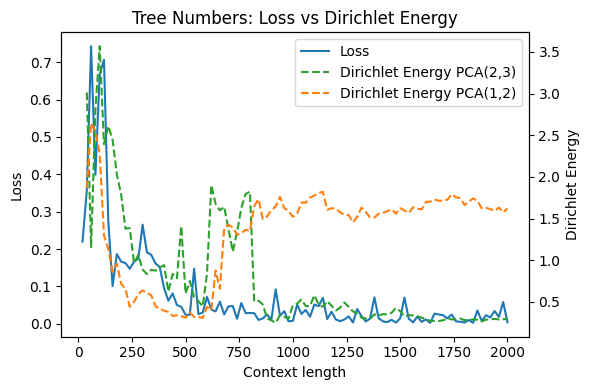

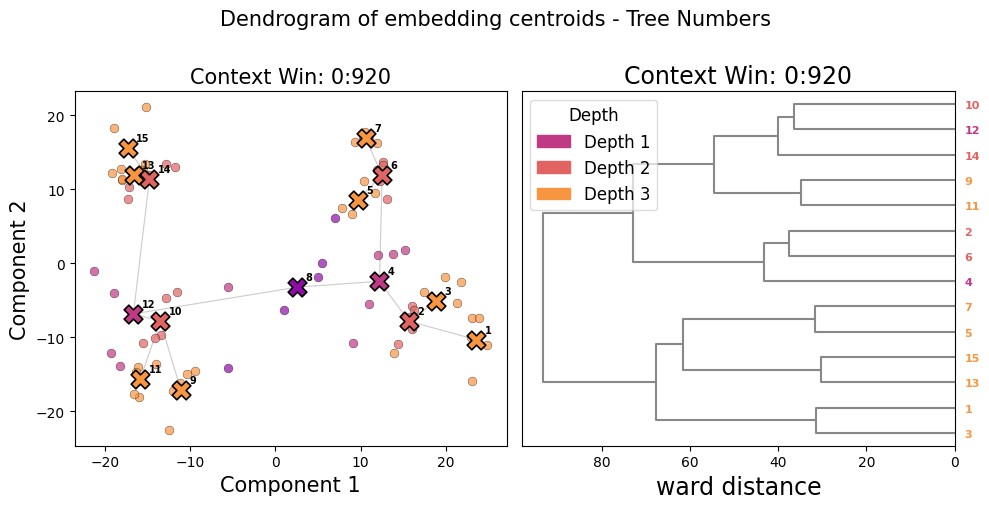

In [6]:
directory = "tree_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "tree"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

k_last = 5
pc1, pc2 = 1, 2

x_tokens, loss_tree, energy_tree = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=3,
    pc1=pc1,
    pc2=pc2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

_, _, energy_tree12 = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=3,
    pc1=0,
    pc2=1,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_tree, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_tree, "--", label=f"Dirichlet Energy PCA({pc1+1},{pc2+1})", color="tab:green")
ax2.set_ylabel("Dirichlet Energy")

# ax2 = ax1.twinx()
line3 = ax2.plot(x_tokens, energy_tree12, "--", label=f"Dirichlet Energy PCA({1},{2})", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[5:][np.argmin(energy_tree[5:])])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                    k=k_last, t_start=0, t_end=win_opt)


pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:,[pc1, pc2]]

hp_tree.plot_reduced_emb(axes[0], pca_result, filtered_ids, title=f"Context Win: 0:{win_opt}", only_centroid=False, second_components=True)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)


# -------------------------------- DENDROGRAM -------------------------------- #

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 2 # quale livello dell'albero dendrogrammo per i centroidi
layer3 = 1

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2 or depth == layer3]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

mask_layer_l = np.isin(ids_np, ids_layer_l)
emb_dendro = emb_np[mask_layer_l]
ids_dendro = ids_np[mask_layer_l]


centroids_id, centroids_emb = centroids_by_token(ids_dendro, emb_dendro)

hp_tree.plot_dendrogram_on_points(axes[1], centroids_id, centroids_emb, title=f"Context Win: 0:{win_opt}", 
                                  method="ward", max_leaves=50, leaf_font_size=8)

fig.suptitle(f"Dendrogram of embedding centroids - {directory.replace('_', ' ').title()}",
             fontsize=15, y=1.01)


fig.tight_layout()
fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

## Grid

  [ctx=2000, win_len=20, local=[0:20)] Warning: token '15' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '13' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '12' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '16' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '9' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '10' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '13' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning:

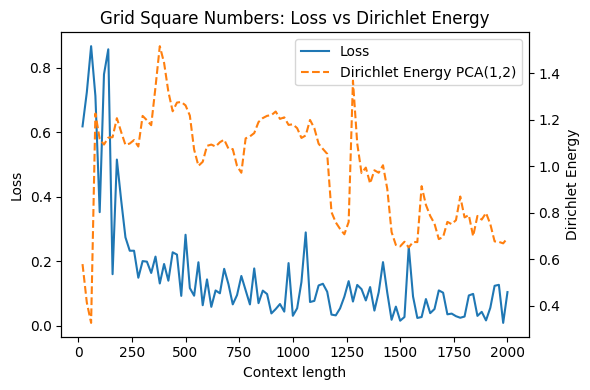

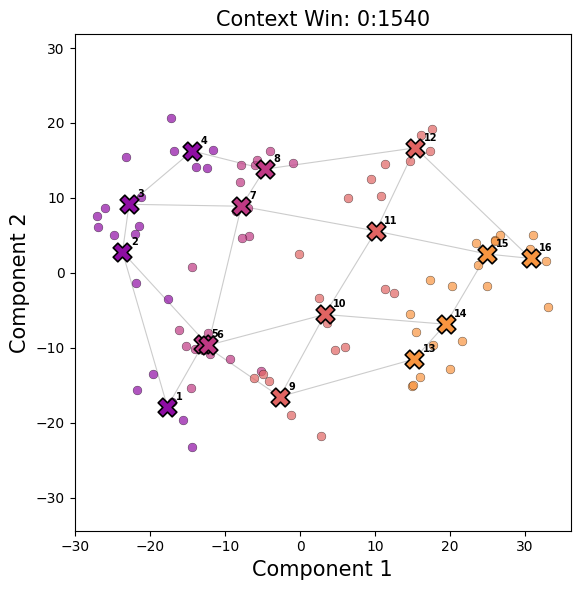

In [7]:
directory = "grid_square_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)
k_last = 5

x_tokens, loss_grid, energy_grid = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_grid, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()

line2 = ax2.plot(x_tokens, energy_grid, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[20:][np.argmin(energy_grid[20:])])

fig, ax = plt.subplots(figsize=(6, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, :2]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal', adjustable='datalim')
ax.set_box_aspect(1)  # force square axes
fig.tight_layout()
fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

## Grid shuffled

  [ctx=2000, win_len=20, local=[0:20)] Warning: token '16' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '12' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '1' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '2' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '3' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '4' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '5' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '11' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: tok

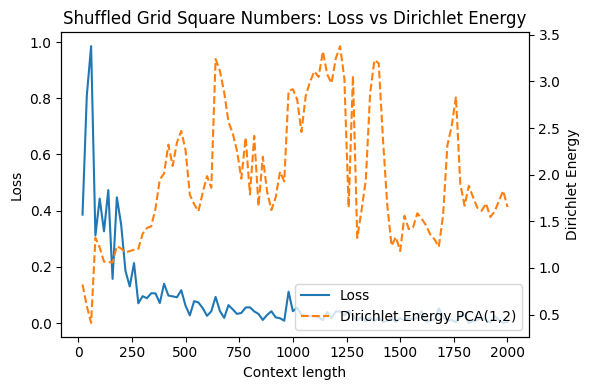

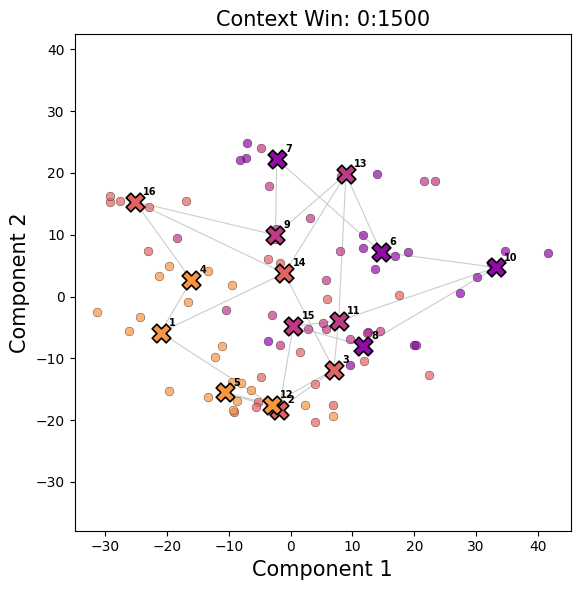

In [8]:
directory = "shuffled_grid_square_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)
k_last = 5

x_tokens, loss_shuffled_grid, energy_shuffled_grid = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_shuffled_grid, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()

line2 = ax2.plot(x_tokens, energy_shuffled_grid, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[20:][np.argmin(energy_shuffled_grid[20:])])

fig, ax = plt.subplots(figsize=(6, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, :2]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal', adjustable='datalim')
ax.set_box_aspect(1)  # force square axes
fig.tight_layout()
fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

## Grid ord + circle ord

  [ctx=2000, win_len=20, local=[0:20)] Warning: token '15' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '13' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '12' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '16' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '9' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '10' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '13' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning:

/tmp/ipykernel_11279/1168766053.py:74: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "--" (-> linestyle='--'). The keyword argument will take precedence.
  line2 = ax2.plot(x_tokens, energy_grid, "--", label=f"Dirichlet Energy Grid PCA({pc_to_plot[0]+1},{pc_to_plot[1]+1})", color=energy_color, **energy_styles["Grid"])
/tmp/ipykernel_11279/1168766053.py:78: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "--" (-> linestyle='--'). The keyword argument will take precedence.
  line3 = ax2.plot(x_tokens, energy_grid2, "--", label=f"Dirichlet Energy Circle PCA({pc_to_plot[0]+1},{pc_to_plot[1]+1})", color=energy_color, **energy_styles["Circle"])


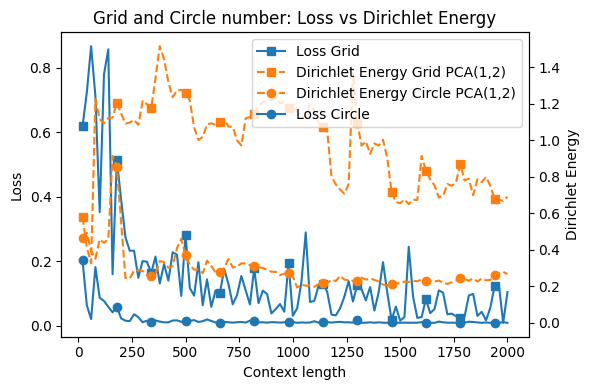

In [9]:
# solo loss in unico grafico
directory = "grid_square_numbers"
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

x_tokens, loss_grid, energy_grid = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    pc1=pc_to_plot[0],
    pc2=pc_to_plot[1],
    k_last=k_last,
    step_topk=10,
    layer=32,
)

directory = "circle_numbers"
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

_, loss_grid2, energy_grid2 = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    pc1=pc_to_plot[0],
    pc2=pc_to_plot[1],
    k_last=k_last,
    step_topk=10,
    layer=32,
)

loss_color = "tab:blue"
energy_color = "tab:orange"

# stili per shape
loss_styles = {
    "Circle": dict(linestyle="-",  marker="o", markevery=8),
    "Grid":   dict(linestyle="-",  marker="s", markevery=8),
    "Tree":   dict(linestyle="-",  marker="^", markevery=8),
}

energy_styles = {
    "Circle": dict(linestyle="--", marker="o", markevery=8),              # dashed
    "Grid":   dict(linestyle="--", marker="s", markevery=8),              # dash-dot
    "Tree":   dict(linestyle="--",  marker="^", markevery=8),              # dotted
}

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_grid, label="Loss Grid", color=loss_color, **loss_styles["Grid"])
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_grid, "--", label=f"Dirichlet Energy Grid PCA({pc_to_plot[0]+1},{pc_to_plot[1]+1})", color=energy_color, **energy_styles["Grid"])
ax2.set_ylabel("Dirichlet Energy")


line3 = ax2.plot(x_tokens, energy_grid2, "--", label=f"Dirichlet Energy Circle PCA({pc_to_plot[0]+1},{pc_to_plot[1]+1})", color=energy_color, **energy_styles["Circle"])

line4 = ax2.plot(x_tokens, loss_grid2, label="Loss Circle", color=loss_color, **loss_styles["Circle"])

lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="upper right")

plt.title("Grid and Circle number: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

## Circle

  [ctx=2000, win_len=20, local=[0:20)] Warning: token '15' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '1' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '2' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '3' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '4' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '5' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '6' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: toke

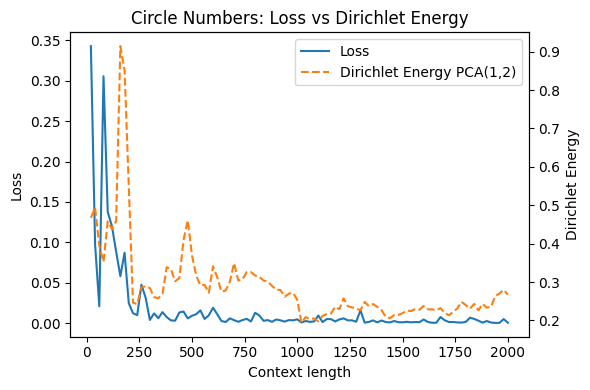

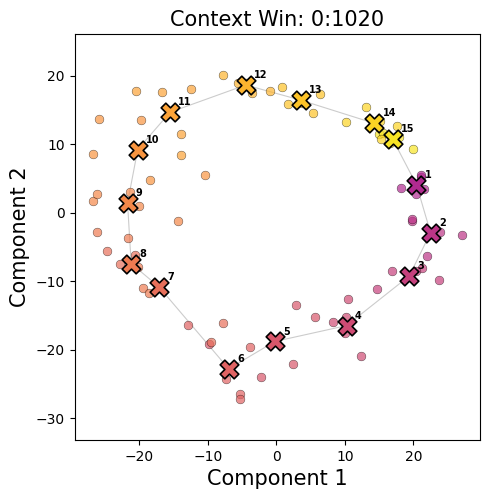

In [10]:
directory = "circle_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

x_tokens, loss_circle, energy_circle = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_circle, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_circle, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
#fig.savefig(f"../plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[2:][np.argmin(energy_circle[2:])])

fig, ax = plt.subplots(figsize=(5, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, :2]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal', adjustable='datalim')
ax.set_box_aspect(1)  # force square axes
fig.tight_layout()

fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

## Circle shuffled

  [ctx=2000, win_len=20, local=[0:20)] Warning: token '15' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '11' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '13' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '2' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '7' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '8' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '9' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: to

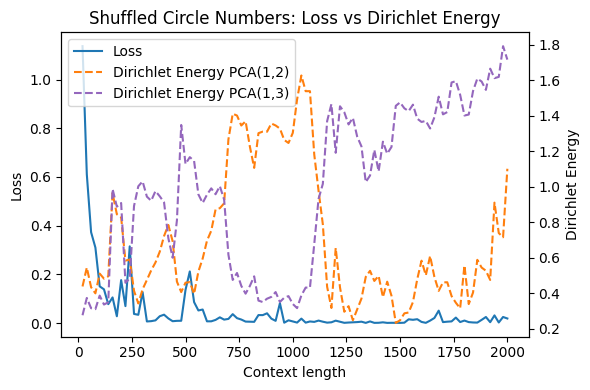

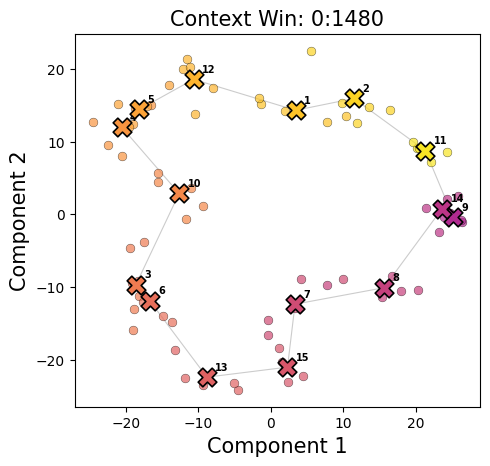

In [11]:
directory = "shuffled_circle_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

x_tokens, loss_circle, energy_circle = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    pc1=pc_to_plot[0],
    pc2=pc_to_plot[1],
    k_last=k_last,
    step_topk=10,
    layer=32,
)

_, _, energy_circle2 = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    pc1=pc_to_plot[0],
    pc2=pc_to_plot[1]+1,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_circle, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_circle, "--", label=f"Dirichlet Energy PCA({pc_to_plot[0]+1},{pc_to_plot[1]+1})", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

line3 = ax2.plot(x_tokens, energy_circle2, "--", label=f"Dirichlet Energy PCA({pc_to_plot[0]+1},{pc_to_plot[1]+2})", color="tab:purple")

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[2:][np.argmin(energy_circle[2:])])

fig, ax = plt.subplots(figsize=(5, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, pc_to_plot]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal')
fig.tight_layout()

fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

  [ctx=2000, win_len=20, local=[0:20)] Warning: token '15' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '11' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '13' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '2' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '7' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '8' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '9' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: to

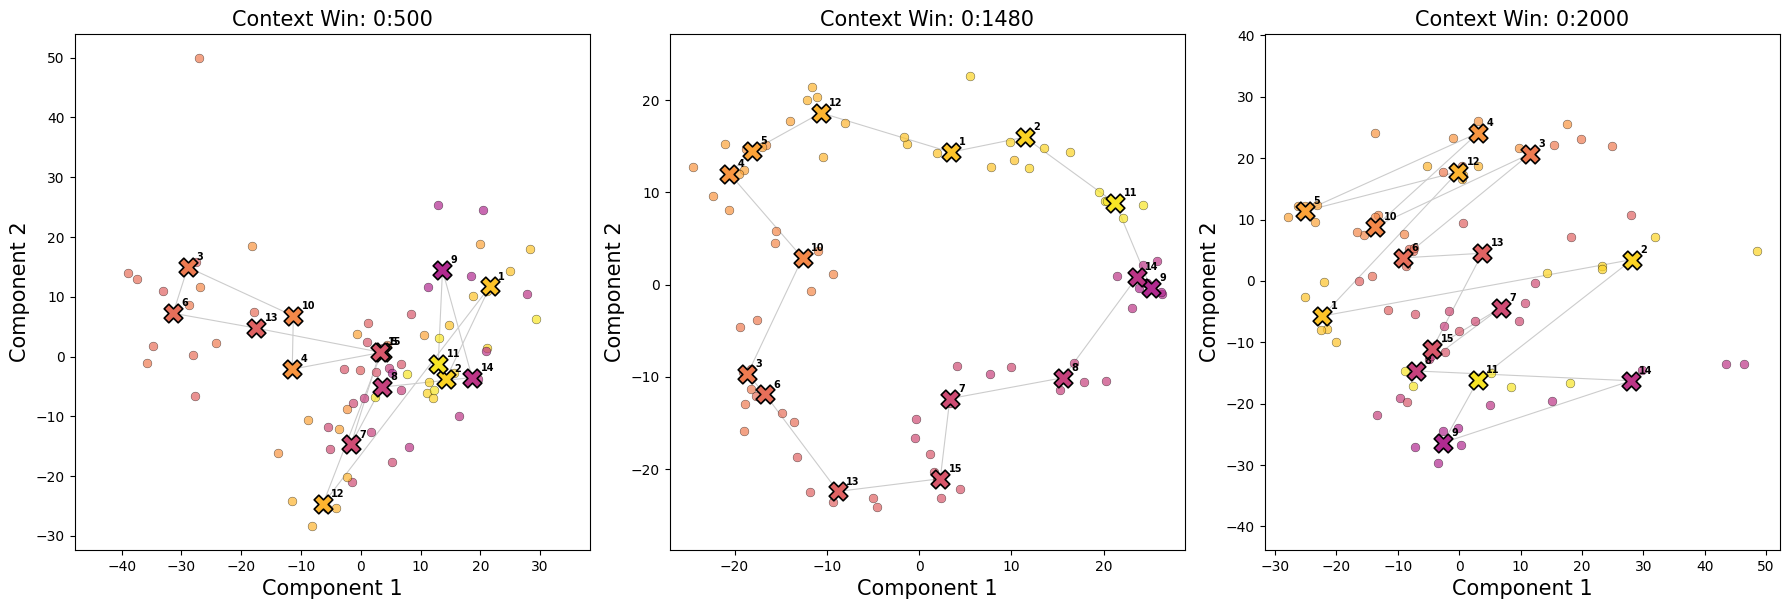

In [12]:
directory = "shuffled_circle_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

x_tokens, loss_circle, energy_circle = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    pc1=pc_to_plot[0],
    pc2=pc_to_plot[1],
    k_last=k_last,
    step_topk=10,
    layer=32,
)

win_opt = int(x_tokens[2:][np.argmin(energy_circle[2:])])

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)


t_ends = [500, win_opt, 2000]  # your three context lengths
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 3 columns

for ax, t_end in zip(axes, t_ends):
    # Load embeddings and filter for the current window
    filtered_ids, filtered_embs = _window_and_filter(
        ids_np, emb_np, hp_tree.id_to_word,
        k=k_last, t_start=0, t_end=t_end
    )
    
    # PCA projection
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:, pc_to_plot]
    
    # Plot
    hp_tree.plot_reduced_emb(
        ax, pca_result, filtered_ids,
        title=f"Context Win: 0:{t_end}", only_centroid=False
    )
    
    # Equal axes
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_box_aspect(1)  # forces axes rectangle to be square

fig.tight_layout()
fig.savefig(f"./plots/pca_{directory}_transition.png", dpi=300, bbox_inches="tight")
plt.show()

  [ctx=2000, win_len=20, local=[0:20)] Warning: token '15' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '11' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '13' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '2' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '7' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '8' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '9' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: to

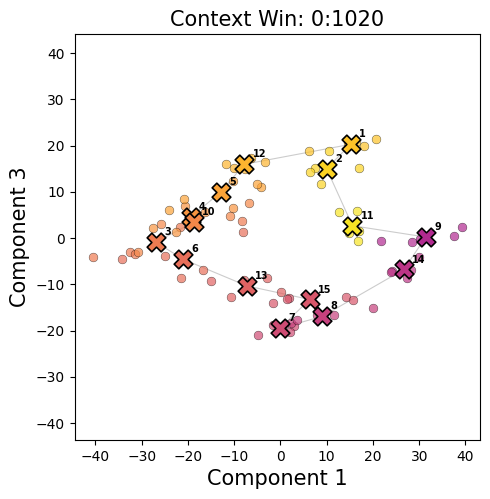

In [13]:
directory = "shuffled_circle_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

k_last = 5
pc_to_plot = (0, 2)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

x_tokens, loss_circle, energy_circle = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    pc1=pc_to_plot[0],
    pc2=pc_to_plot[1],
    k_last=k_last,
    step_topk=10,
    layer=32,
)


win_opt = int(x_tokens[15:][np.argmin(energy_circle[15:])])

fig, ax = plt.subplots(figsize=(5, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, pc_to_plot]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False, pc1=pc_to_plot[0], pc2=pc_to_plot[1]
)

ax.set_aspect('equal', adjustable='datalim')
ax.set_box_aspect(1)  # force square axes
fig.tight_layout()

fig.savefig(f"./plots/pca_{directory}_13.png", dpi=300, bbox_inches="tight")
plt.show()

# Days

## Tree

[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Monday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Wednesday' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Sunday' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'Thursday' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'Friday' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token 'Thursday' has only 1 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token 'Friday' has only 1 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=100, local=[0:

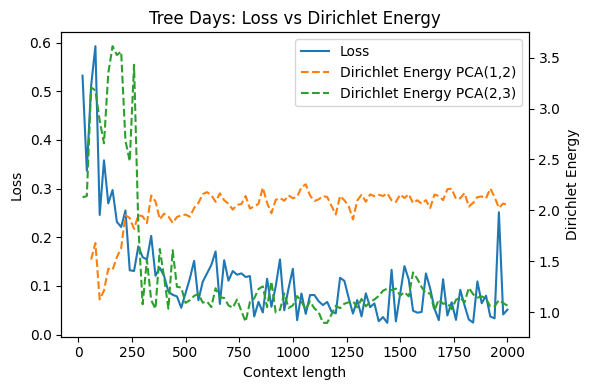

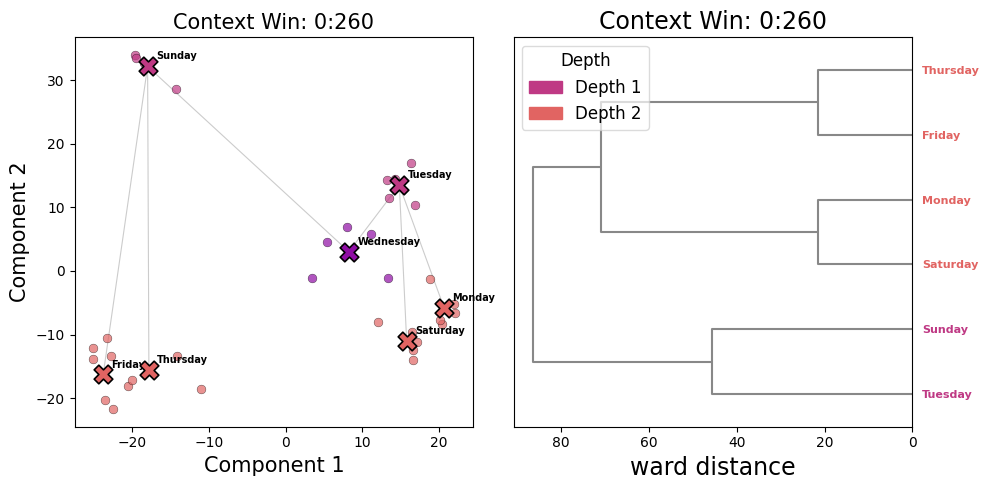

In [14]:
directory = "tree_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "tree"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

k_last = 5
pc1, pc2 = 0, 1

x_tokens, loss_tree, energy_tree = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=5,
    pc1=pc1,
    pc2=pc2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

_, _, energy_circle2 = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    pc1=pc1+1,
    pc2=pc2+1,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_tree, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_tree, "--", label=f"Dirichlet Energy PCA({pc1+1},{pc2+1})", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

line3 = ax2.plot(x_tokens, energy_circle2, "--", label=f"Dirichlet Energy PCA({pc1+2},{pc2+2})", color="tab:green")

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

##############################################################################
win_opt = int(x_tokens[12:][np.argmin(energy_tree[12:])])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))


embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                    k=k_last, t_start=0, t_end=win_opt)


pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:,[pc1, pc2]]

hp_tree.plot_reduced_emb(axes[0], pca_result, filtered_ids, title=f"Context Win: 0:{win_opt}", only_centroid=False, pc1=pc1, pc2=pc2)

# fig.suptitle(directory.replace("_", " ").title(),
#              fontsize=20, y=1.01)


# -------------------------------- DENDROGRAM -------------------------------- #

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 2 # quale livello dell'albero dendrogrammo per i centroidi
layer3 = 1

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2 or depth == layer3]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

mask_layer_l = np.isin(ids_np, ids_layer_l)
emb_dendro = emb_np[mask_layer_l]
ids_dendro = ids_np[mask_layer_l]


centroids_id, centroids_emb = centroids_by_token(ids_dendro, emb_dendro)

hp_tree.plot_dendrogram_on_points(axes[1], centroids_id, centroids_emb, title=f"Context Win: 0:{win_opt}", 
                                  method="ward", max_leaves=50, leaf_font_size=8)

# fig.suptitle(f"Dendrogram Tree Days",
#              fontsize=15, y=1.01)


fig.tight_layout()
fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Monday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Wednesday' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Sunday' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'Thursday' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'Friday' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token 'Thursday' has only 1 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token 'Friday' has only 1 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=100, local=[0:

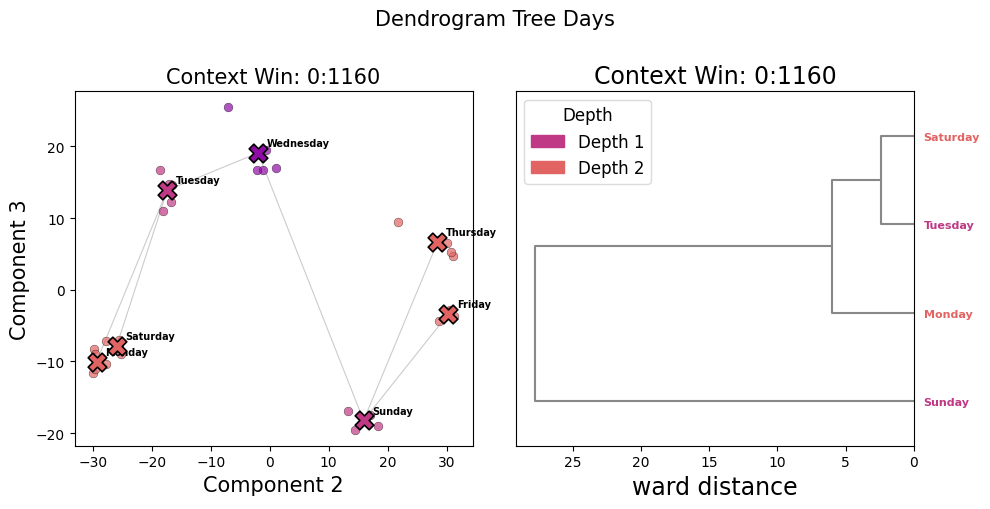

In [15]:
directory = "tree_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "tree"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

k_last = 5
pc1, pc2 = 1, 2

x_tokens, loss_tree, energy_tree = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=5,
    pc1=pc1,
    pc2=pc2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

win_opt = int(x_tokens[12:][np.argmin(energy_tree[12:])])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))


embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                    k=k_last, t_start=0, t_end=win_opt)


pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:,[pc1, pc2]]

hp_tree.plot_reduced_emb(axes[0], pca_result, filtered_ids, title=f"Context Win: 0:{win_opt}", only_centroid=False, pc1=pc1, pc2=pc2)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)


# -------------------------------- DENDROGRAM -------------------------------- #

layer = 2 # quale livello dell'albero dendrogrammo
layer2 = 1 # quale livello dell'albero dendrogrammo per i centroidi
# layer3 = 2

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

mask_layer_l = np.isin(ids_np, ids_layer_l)
emb_dendro = emb_np[mask_layer_l]
ids_dendro = ids_np[mask_layer_l]


centroids_id, centroids_emb = centroids_by_token(ids_dendro, pca_result)

hp_tree.plot_dendrogram_on_points(axes[1], centroids_id, centroids_emb, title=f"Context Win: 0:{win_opt}", 
                                  method="ward", max_leaves=50, leaf_font_size=8)

fig.suptitle(f"Dendrogram Tree Days",
             fontsize=15, y=1.01)


fig.tight_layout()
fig.savefig(f"./plots/pca_{directory}_23.png", dpi=300, bbox_inches='tight')
plt.show()

## Grid

[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Friday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 4 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Friday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Thursday' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'Thursday' has only 4 occurrences in [0:60] (requested 5)
Total windows: 100
Valid energy windows: 100
Dropped windows: 0


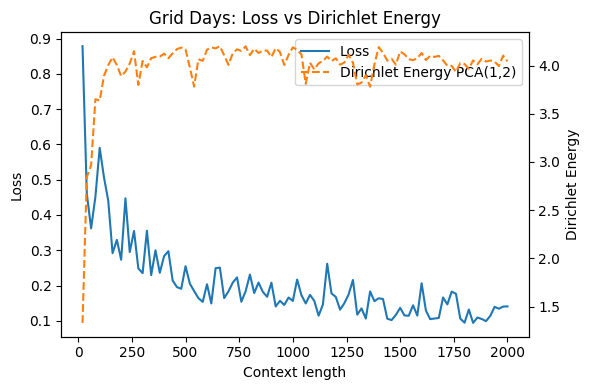

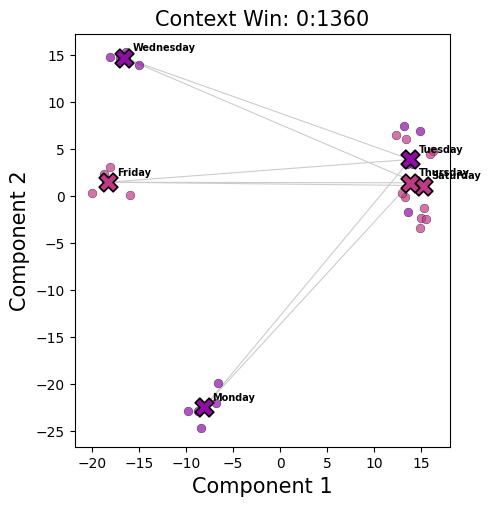

In [16]:
directory = "grid_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)
k_last = 5

x_tokens, loss_grid, energy_grid = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_grid, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()

line2 = ax2.plot(x_tokens, energy_grid, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[20:][np.argmin(energy_grid[20:])])

fig, ax = plt.subplots(figsize=(5, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, :2]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal')
fig.tight_layout()

fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

## Grid shuffled

[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Monday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Thursday' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 4 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Friday' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'Friday' has only 4 occurrences in [0:60] (requested 5)
Total windows: 100
Valid energy windows: 100
Dropped windows: 0


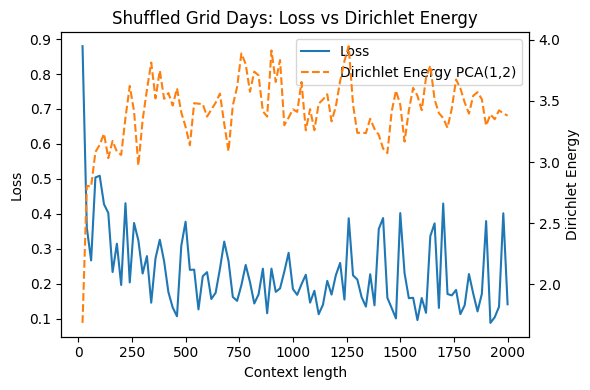

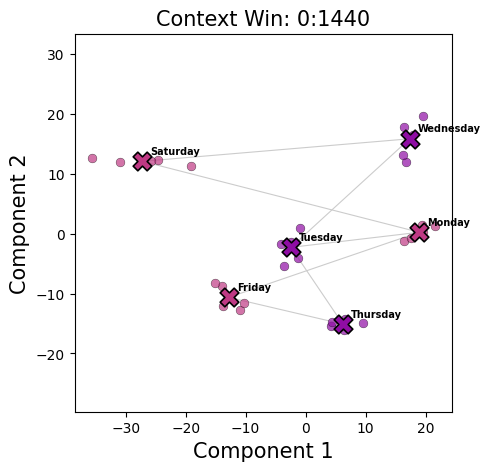

In [17]:
directory = "shuffled_grid_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)
k_last = 5

x_tokens, loss_grid, energy_grid = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_grid, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()

line2 = ax2.plot(x_tokens, energy_grid, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
#fig.savefig(f"../plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[20:][np.argmin(energy_grid[20:])])

fig, ax = plt.subplots(figsize=(5, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, :2]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal', adjustable='datalim')
ax.set_box_aspect(1)  # force square axes
fig.tight_layout()

#fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Friday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 4 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Friday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Thursday' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'Thursday' has only 4 occurrences in [0:60] (requested 5)
Total windows: 100
Valid energy windows: 100
Dropped windows: 0
[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Monday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 2 occurrences in [0:20] (requested 5)
  [ct

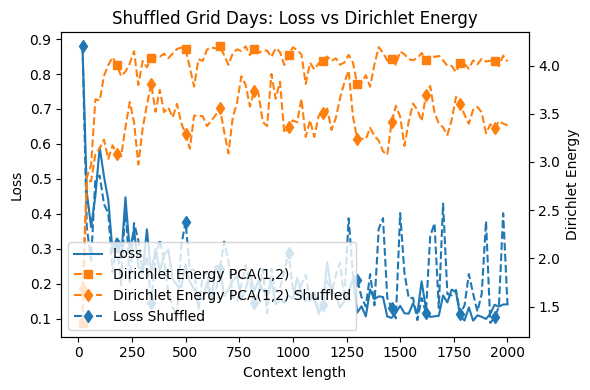

In [18]:
directory = "grid_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)
k_last = 5

x_tokens, loss_grid, energy_grid = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

directory = "shuffled_grid_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)
k_last = 5

x_tokens, loss_shuffled_grid, energy_shuffled_grid = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_grid, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()

line2 = ax2.plot(x_tokens, energy_grid, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange", marker="s",markevery=8)
ax2.set_ylabel("Dirichlet Energy")

line3 = ax2.plot(x_tokens, energy_shuffled_grid, "--", label="Dirichlet Energy PCA(1,2) Shuffled", color="tab:orange", marker="d",markevery=8)

line4 = ax1.plot(x_tokens, loss_shuffled_grid, label="Loss Shuffled", color="tab:blue", linestyle="--", marker="d", markevery=8)

lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="lower left")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()


## Circle

[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Sunday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Thursday' has only 4 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Sunday' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Tuesday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Wednesday' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Tuesday' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0

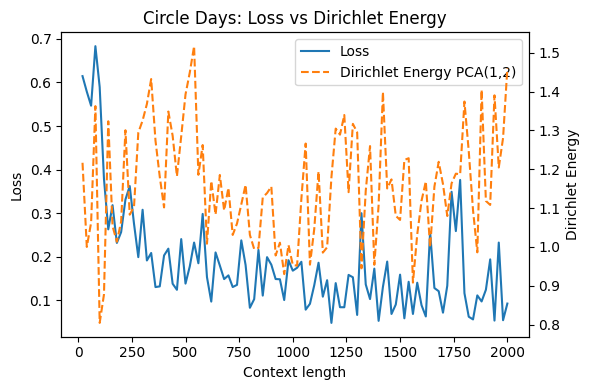

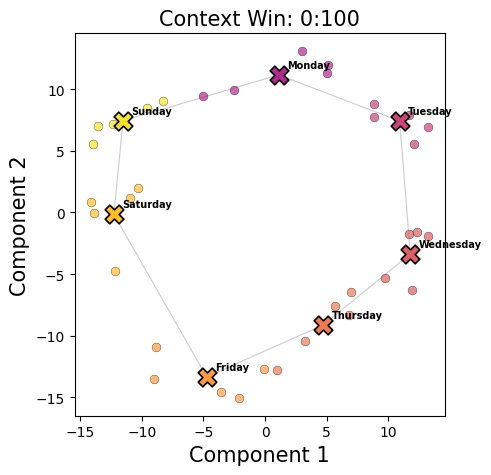

In [19]:
directory = "circle_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

x_tokens, loss_circle, energy_circle = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_circle, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_circle, "--", label="Dirichlet Energy PCA(1,2)", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()
win_opt = int(x_tokens[2:][np.argmin(energy_circle[2:])])

fig, ax = plt.subplots(figsize=(5, 6))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, :2]

hp_tree.plot_reduced_emb(
    ax, pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt}", only_centroid=False
)

ax.set_aspect('equal')
fig.tight_layout()

fig.savefig(f"./plots/pca_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

## Circle shuffled

[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Saturday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Thursday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 4 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Friday' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Tuesday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Thursday' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Friday' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0

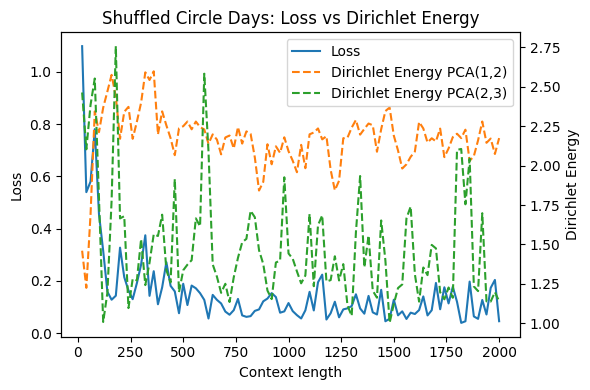

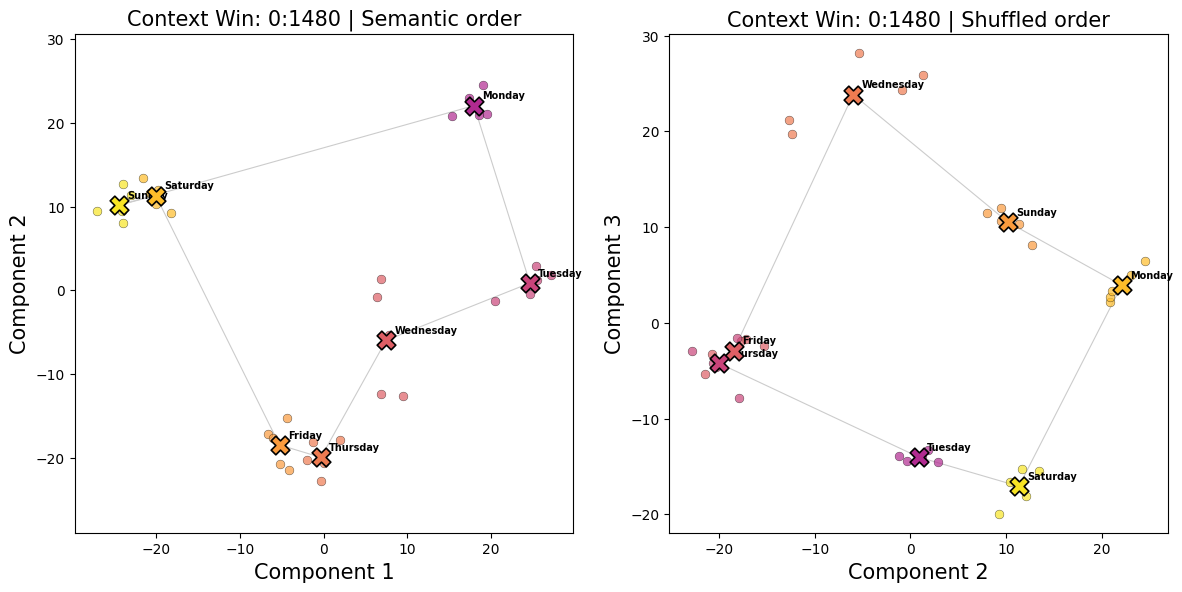

In [20]:
directory = "shuffled_circle_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/circle_days/structure.txt")

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

x_tokens, loss_circle, energy_circle = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    pc1=pc_to_plot[0],
    pc2=pc_to_plot[1],
    k_last=k_last,
    step_topk=10,
    layer=32,
)

_, _, energy_circle2 = compute_aligned_loss_energy(
    directory=directory,
    vocab_path=VOCAB_PATH,
    graph_kind=graph_kind,
    win=20,
    pca_k=2,
    pc1=pc_to_plot[0]+1,
    pc2=pc_to_plot[1]+1,
    k_last=k_last,
    step_topk=10,
    layer=32,
)

fig, ax1 = plt.subplots(figsize=(6, 4))

line1 = ax1.plot(x_tokens, loss_circle, label="Loss", color="tab:blue")
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid(False)

ax2 = ax1.twinx()
line2 = ax2.plot(x_tokens, energy_circle, "--", label=f"Dirichlet Energy PCA({pc_to_plot[0]+1},{pc_to_plot[1]+1})", color="tab:orange")
ax2.set_ylabel("Dirichlet Energy")

line3 = ax2.plot(x_tokens, energy_circle2, "--", label=f"Dirichlet Energy PCA({pc_to_plot[0]+2},{pc_to_plot[1]+2})", color="tab:green")

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_',' ').title()}: Loss vs Dirichlet Energy")
fig.tight_layout()
fig.savefig(f"./plots/loss_{directory}.png", dpi=300, bbox_inches="tight")
plt.show()

win_opt = int(x_tokens[4:][np.argmin(energy_circle2[4:])])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

pc_pairs = [(0, 1), (1, 2)]  # PCA(1,2) and PCA(2,3)
titles = ["Semantic order", "Shuffled order"]

# Filter embeddings for the same context window
filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

# PCA projection
pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, (0, 1)]

# Plot on this axes
hp_tree.plot_reduced_emb(
    axes[0], pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt} | {titles[0]}",
    only_centroid=False,
    pc1=0, pc2=1
)

# Make axes square
axes[0].set_aspect('equal', adjustable='datalim')
axes[0].set_box_aspect(1)

filtered_ids, filtered_embs = _window_and_filter(
    ids_np, emb_np, hp_tree.id_to_word,
    k=k_last, t_start=0, t_end=win_opt
)

# PCA projection
pca = PCA(n_components=5)
pca_result = pca.fit_transform(filtered_embs)[:, (1, 2)]

STRUCT_PATH = Path(f"../data/one_random_walk/shuffled_circle_days/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

# Plot on this axes
hp_tree.plot_reduced_emb(
    axes[1], pca_result, filtered_ids,
    title=f"Context Win: 0:{win_opt} | {titles[1]}",
    only_centroid=False,
    pc1=1, pc2=2
)

# Make axes square
axes[1].set_aspect('equal', adjustable='datalim')
axes[1].set_box_aspect(1)

fig.tight_layout()
fig.savefig(f"./plots/pca_{directory}_12_23.png", dpi=300, bbox_inches="tight")
plt.show()